# **Работа выполнена студентами программы "Экономика и анализ данных"**

# **Коркодинов Павел Алексеевич**

# **Бараненков Никита Максимович**

# **Докучаев Алексей Евгеньевич**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Если необходимо, установите библиотеку pyreadstat:
!pip install pyreadstat
# Для извлечения датасета по ссылке -- gdown:
!pip install -q gdown
import gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 15.8 MB/s eta 0:00:00


# Задание №0: Загрузка и предварительная обработка данных

1. Загрузите данные RLMS (например, в формате .sav) с официального источника [RLMS](https://hse.ru/rlms).

2. Выполните очистку и гармонизацию данных:
- Приведение имён столбцов к нижнему регистру и удаление лишних пробелов.
- Обработка пропусков и рекодирование категориальных переменных.
- Объединение домохозяйственных и индивидуальных анкет (используйте переменные вида `bbidindX`).

**Скачивание датасетов с Гугл Диска:**

In [ ]:
# Скачиваем файл
# Идивиды 2023
file_id = '1LvfNtzb7FJMF0kVIQtcQ_h6HGvpXZoHm'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'r32i_os_73.sav'
gdown.download(url, output, quiet=False)
# Читаем SPSS-файл
try:
    rlms_df_i_23 = pd.read_spss(output, convert_categoricals=False) # тут мы и делаем рекодирование - convert_categoricals=False
    print("Файл успешно загружен!")
except Exception as e:
    print(f"Ошибка загрузки: {e}")


Downloading...
From: https://drive.google.com/uc?id=1LvfNtzb7FJMF0kVIQtcQ_h6HGvpXZoHm
To: /content/r32i_os_73.sav
100%|██████████| 15.2M/15.2M [00:00<00:00, 23.9MB/s]


Файл успешно загружен!


In [ ]:
# Скачиваем файл
# Домохозяйства 2023
file_id = '1NhU8ERvp3tuzVTBCAd_VmZ5ZmBuw1bww'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'r32h_os_71.sav'
gdown.download(url, output, quiet=False)
# Читаем SPSS-файл
try:
    rlms_df_h_23 = pd.read_spss(output, convert_categoricals=False) # тут мы и делаем рекодирование
    print("Файл успешно загружен!")
except Exception as e:
    print(f"Ошибка загрузки: {e}")

Downloading...
From: https://drive.google.com/uc?id=1NhU8ERvp3tuzVTBCAd_VmZ5ZmBuw1bww
To: /content/r32h_os_71.sav
100%|██████████| 9.19M/9.19M [00:00<00:00, 48.6MB/s]


Файл успешно загружен!


In [ ]:
# Скачиваем файл
# Домохозяйства 2014
file_id = '1m7PwX6oIQaYFv71ZHwriPuTaY3d-kB7R'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'r23h_os41.sav'
gdown.download(url, output, quiet=False)
# Читаем SPSS-файл
try:
    rlms_df_h_14 = pd.read_spss(output, convert_categoricals=False) # тут мы и делаем рекодирование
    print("Файл успешно загружен!")
except Exception as e:
    print(f"Ошибка загрузки: {e}")

Downloading...
From: https://drive.google.com/uc?id=1m7PwX6oIQaYFv71ZHwriPuTaY3d-kB7R
To: /content/r23h_os41.sav
100%|██████████| 8.66M/8.66M [00:00<00:00, 102MB/s]


Файл успешно загружен!


In [ ]:
rlms_df_h_23.head()

,bbredid_h,bbid_h,aaid_h,zid_h,yid_h,xid_h,wid_h,vid_h,uid_h,tid_h,...,bbf16.4,bbf16.5,bbg1.1,bbg1.2,bbg2,bbg3,bbg4,bbg5,bbg6,bbg7
0,663.0,10003.0,10003.0,10003.0,10003.0,10003.0,10003.0,10003.0,10003.0,10003.0,...,2.0,99999996.0,2.0,2.0,1.0,2.0,3.0,2.0,3.0,1.0
1,666.0,10014.0,10014.0,10014.0,10014.0,10014.0,10014.0,10014.0,10014.0,10014.0,...,2.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,1.0
2,667.0,10016.0,10016.0,10016.0,10016.0,10016.0,10016.0,10016.0,10016.0,10016.0,...,2.0,2.0,1.0,1.0,1.0,2.0,3.0,2.0,1.0,2.0
3,668.0,10018.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,2.0,2.0,3.0,2.0,1.0,2.0,1.0,2.0
4,669.0,10023.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,1.0,2.0,2.0,1.0,3.0,3.0,1.0,2.0


**Выполните очистку и гармонизацию данных:**

1. Приведение имён столбцов к нижнему регистру и удаление лишних пробелов:

In [ ]:
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower()
    return df

rlms_df_i_23 = clean_columns(rlms_df_i_23)
rlms_df_h_23 = clean_columns(rlms_df_h_23)
rlms_df_h_14 = clean_columns(rlms_df_h_14)

2. Обработка пропусков и рекодирование категориальных переменных:

In [ ]:
#делать обработку пропусков для наших целей нет смысла, а рекодирование сделали ранее

3. Объединение домохозяйственных и индивидуальных анкет:

In [ ]:
#сделали это далее, собрали удобную для анализа таблицу

# Задание 4: Дети и родители

В этом задании вам нужно изучить, как характеристики родителей влияют на характеристики их детей. Для этого вы будете использовать данные опроса RLMS за последние 10 доступных лет (с 2014 по 2023 гг.).

Данные RLMS имеют панельную структуру, то есть, каждый год организаторы исследования стараются опрашивать одних и тех же людей. Это позволяет изучать не просто характеристики индивидов в данный год, но и их динамику, благодаря чему мы можем формулировать и проверять очень нетривиальные гипотезы. Для того, чтобы найти данного человека в опроснике за другой год, вы можете воспользоваться переменной «idind» или переменными вида «**X**id_i» (для ID индивида), «**X**id_h» (для ID его домохозяйства), где X – номер волны опроса. Случается так, что индивиды перестают участвовать в опросе (и тогда организаторы находят новых участников), в этом случае для них не получится найти данные за последующие годы, а для вновь добавленных в исследование респондентов – их предысторию. Это важный момент, который стоит учитывать.

Для того, чтобы понять родственные связи членов домохозяйства, мы будем использовать переменные из опросника по домохозяйствам вида «bbb**X**.9.**Y**»,  где X и Y – номера членов домохозяйства. Из этих показателей несложно восстановить полную структуру семьи.

Для того, чтобы подтянуть к характеристикам домохозяйства данные по отдельным его членам, вы можете использовать переменные вида «bbidind**X**», (где X – номер члена домохозяйства): в них находятся идентификационные номера членов семьи, по которым их можно найти в опроснике по индивидам.

### 4.1 Наличие данных о родителях

Найдите всех индивидов, представленных в опросе 2023 года, для которых можно найти хотя бы одного из их родителей. Имейте в виду, что, к примеру, в последней волне (2023 года) индивиды могут проживать отдельно от родителей, но в одной из предыдущих волн они могли проживать совместно – и тогда вы сможете подтянуть характеристики родителей из опросников за другие годы.

Посчитайте, для какого числа индивидов в данных нет информации ни об одном из родителей, для какого числа есть данных только о матери, только об отце, об обоих родителях?

Для каждого ребенка из домохозяйств 2023 найдем его родителя/-ей children_23.

Для этого берем только те колонки, которые характеризуют
- родственные связи
- ID члена семьи
- пол члена семьи (чтобы определить мать/отец)

In [ ]:
import re

# Использование шаблонов
pattern1 = r'^bbb\d+\.9\.\d+$'   # родственные связи между X и Y
pattern2 = r'^bbb\d+\.4$'        # пол человека с номером X
pattern3 = r'^bbidind\d+$'       # id человека с номером X

filtered_df1 = rlms_df_h_23.filter(regex=pattern1, axis=1)  # родственные связи
filtered_df2 = rlms_df_h_23.filter(regex=pattern2, axis=1)  # пол
filtered_df3 = rlms_df_h_23.filter(regex=pattern3, axis=1)  # id

# Добавление индекса для последующего удаления пустых строк категорий
filtered_df1 = filtered_df1.copy()
filtered_df1["merge_index"] = filtered_df1.index

filtered_df2 = filtered_df2.copy()
filtered_df2["merge_index"] = filtered_df2.index

filtered_df3 = filtered_df3.copy()
filtered_df3["merge_index"] = filtered_df3.index

# Удаление пустых строк категорий
filtered_df1.dropna(how='all', inplace=True)
cols_without_index = filtered_df1.columns.difference(["merge_index"])
filtered_df1 = filtered_df1.dropna(subset=cols_without_index, how='all')

# Слияние в одну таблицу
merged = (
    filtered_df1
    .merge(filtered_df2, on="merge_index", how="left")
    .merge(filtered_df3, on="merge_index", how="left")
)
merged.drop(columns=["merge_index"], inplace=True)

print(f"Финальный размер таблицы: {merged.shape}")

merged.head()

Финальный размер таблицы: (3372, 186)


,bbb2.9.1,bbb3.9.1,bbb3.9.2,bbb4.9.1,bbb4.9.2,bbb4.9.3,bbb5.9.1,bbb5.9.2,bbb5.9.3,bbb5.9.4,...,bbidind12,bbidind13,bbidind14,bbidind15,bbidind16,bbidind17,bbidind18,bbidind19,bbidind20,bbidind21
0,1.0,4.0,4.0,4.0,4.0,6.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,12.0,1.0,9.0,4.0,4.0,9.0,4.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Функция для получения искомой таблицы children_23

In [ ]:
# Функция создана нейросетью, что помогло быстро обработать данные и быть уверенным в точности результатов.
import re

def extract_parent_child_relations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Извлекает пары (id_ребенка, id_отца, id_матери) из таблицы домохозяйств.

    Аргументы:
    - df (pd.DataFrame): входная таблица с колонками вида 'bbbX.9.Y', 'bbidindX', 'bbbX.4'

    Возвращает:
    - pd.DataFrame с колонками ['child_id', 'father_id', 'mother_id']
    """
    relations = []

    # Ищем все колонки с отношениями
    relation_columns = [col for col in df.columns if re.match(r'bbb\d+\.9\.\d+$', col)]

    for col in relation_columns:
        match = re.match(r'bbb(\d+)\.9\.(\d+)$', col)
        if not match:
            continue
        x = match.group(1)  # X — первая персона
        y = match.group(2)  # Y — вторая персона

        # Названия колонок с ID и полом
        id_x_col = f'bbidind{x}'
        id_y_col = f'bbidind{y}'
        sex_x_col = f'bbb{x}.4'
        sex_y_col = f'bbb{y}.4'

        for _, row in df.iterrows():
            relation = row[col]
            id_x = row[id_x_col]
            id_y = row[id_y_col]

            # Пропускаем, если ID нет
            if pd.isna(id_x) or pd.isna(id_y):
                continue

            # Полы могут быть NaN, проверим осторожно
            sex_x = row[sex_x_col] if sex_x_col in df.columns else None
            sex_y = row[sex_y_col] if sex_y_col in df.columns else None

            # "Сын/дочь" → X — родитель, Y — ребенок
            if relation == 2: # Отец/мать
                father_id = id_x if sex_x == 1 else None # Мужской
                mother_id = id_x if sex_x == 2 else None # Женский
                relations.append({
                    'child_id': id_y,
                    'father_id': father_id,
                    'mother_id': mother_id
                })

            # "Отец/мать" → X — ребенок, Y — родитель
            elif relation == 4: # Сын/дочь
                father_id = id_y if sex_y == 1 else None # Мужской
                mother_id = id_y if sex_y == 2 else None # Женский
                relations.append({
                    'child_id': id_x,
                    'father_id': father_id,
                    'mother_id': mother_id
                })

    # Объединяем дубликаты по child_id (на случай, если у ребёнка указаны оба родителя отдельно)
    df_relations = pd.DataFrame(relations)

    print(df_relations.head())
    print(df_relations.columns)

    final_df = df_relations.groupby('child_id', as_index=False).agg({
        'father_id': 'first',
        'mother_id': 'first'
    })

    return final_df


In [ ]:
children_23 = extract_parent_child_relations(merged.iloc[:1, :])
children_23

   child_id  father_id  mother_id
0   25033.0        NaN    25032.0
1   25033.0    31341.0        NaN
2   25034.0        NaN    25032.0
3   25034.0    31341.0        NaN
Index(['child_id', 'father_id', 'mother_id'], dtype='object')


,child_id,father_id,mother_id
0,25033.0,31341.0,25032.0
1,25034.0,31341.0,25032.0


Искомая таблица children_23

In [ ]:
# 19 сек.
children_23 = extract_parent_child_relations(merged)
children_23.head()
print(children_23.shape)

   child_id  father_id  mother_id
0   63113.0        NaN    63112.0
1   63116.0        NaN    63115.0
2   52955.0        NaN    52954.0
3   59415.0        NaN    59414.0
4   25122.0        NaN    25121.0
Index(['child_id', 'father_id', 'mother_id'], dtype='object')
(4226, 3)


In [ ]:
children_23.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4226 entries, 0 to 4225
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   child_id   4226 non-null   float64
 1   father_id  2579 non-null   float64
 2   mother_id  4061 non-null   float64
dtypes: float64(3)
memory usage: 99.2 KB


Теперь сделаем все то же самое для данных 2014 года, затем мы уберем тех детей, которые есть в данных 2023, соберем таблицу в одну и посмотрим, есть ли все из них в опросе индивидумов 2023 года

In [ ]:
# Отбираем нужные колонки по шаблонам
pattern1h14 = r'^sb\d+\.9\.\d+$'   # отношения между X и Y
pattern2h14 = r'^sb\d+\.4$'        # пол человека с номером X
pattern3h14 = r'^sidind\d+$'       # id человека с номером X


filtered_df1_h14 = rlms_df_h_14.filter(regex=pattern1h14, axis=1)  # отношения
filtered_df2_h14 = rlms_df_h_14.filter(regex=pattern2h14, axis=1)  # пол
filtered_df3_h14 = rlms_df_h_14.filter(regex=pattern3h14, axis=1)  # id

# Добавим индекс как отдельный столбец для последующего слияния
filtered_df1_h14 = filtered_df1_h14.copy()
filtered_df1_h14["merge_index"] = filtered_df1_h14.index

filtered_df2_h14 = filtered_df2_h14.copy()
filtered_df2_h14["merge_index"] = filtered_df2_h14.index

filtered_df3_h14 = filtered_df3_h14.copy()
filtered_df3_h14["merge_index"] = filtered_df3_h14.index

filtered_df1_h14.dropna(how='all', inplace=True)
cols_without_index = filtered_df1_h14.columns.difference(["merge_index"])
filtered_df1_h14 = filtered_df1_h14.dropna(subset=cols_without_index, how='all')

# Мержим по индексу (inner join — только те строки, что остались после фильтрации)
merged14 = (
    filtered_df1_h14
    .merge(filtered_df2_h14, on="merge_index", how="left")
    .merge(filtered_df3_h14, on="merge_index", how="left")
)

# Удалим merge_index, если он больше не нужен
merged14.drop(columns=["merge_index"], inplace=True)

print(f"Финальный размер таблицы: {merged14.shape}")

merged14.head()

Финальный размер таблицы: (3807, 175)


,sb2.9.1,sb3.9.1,sb3.9.2,sb4.9.1,sb4.9.2,sb4.9.3,sb5.9.1,sb5.9.2,sb5.9.3,sb5.9.4,...,sidind11,sidind12,sidind13,sidind14,sidind15,sidind16,sidind17,sidind18,sidind19,sidind20
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,4.0,4.0,4.0,4.0,6.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Функция создана нейросетью, что помогло быстро обработать данные и быть уверенным в точности результатов.
def extract_parent_child_relations_for_2014(df: pd.DataFrame) -> pd.DataFrame:
    """
    Извлекает пары (id_ребенка, id_отца, id_матери) из таблицы домохозяйств.

    Аргументы:
    - df (pd.DataFrame): входная таблица с колонками вида 'bbbX.9.Y', 'bbidindX', 'bbbX.4'

    Возвращает:
    - pd.DataFrame с колонками ['child_id', 'father_id', 'mother_id']
    """
    relations = []

    # Ищем все колонки с отношениями
    relation_columns = [col for col in df.columns if re.match(r'^sb\d+\.9\.\d+$', col)]

    for col in relation_columns:
        match = re.match(r'^sb(\d+)\.9\.(\d+)$', col) # Нужно экранировать "." и захватывать группы
        if match: # Изменено: Проверяем, что match не None
            x = match.group(1)  # X — первая персона
            y = match.group(2)  # Y — вторая персона

            # Названия колонок с ID и полом
            id_x_col = f'sidind{x}'
            id_y_col = f'sidind{y}'
            sex_x_col = f'sb{x}.4'
            sex_y_col = f'sb{y}.4'

            for _, row in df.iterrows():
                relation = row[col]
                id_x = row[id_x_col]
                id_y = row[id_y_col]

                # Пропускаем, если ID нет
                if pd.isna(id_x) or pd.isna(id_y):
                    continue

                # Полы могут быть NaN, проверим осторожно
                sex_x = row[sex_x_col] if sex_x_col in df.columns else None
                sex_y = row[sex_y_col] if sex_y_col in df.columns else None

                # "Сын/дочь" → X — родитель, Y — ребенок
                if relation == 2:
                    father_id = id_x if sex_x == 1 else None
                    mother_id = id_x if sex_x == 2 else None
                    relations.append({
                        'child_id': id_y,
                        'father_id': father_id,
                        'mother_id': mother_id
                    })

                # "Отец/мать" → X — ребенок, Y — родитель
                elif relation == 4:
                    father_id = id_y if sex_y == 1 else None
                    mother_id = id_y if sex_y == 2 else None
                    relations.append({
                        'child_id': id_x,
                        'father_id': father_id,
                        'mother_id': mother_id
                    })

    # Объединяем дубликаты по child_id (на случай, если у ребёнка указаны оба родителя отдельно)
    df_relations = pd.DataFrame(relations)

    print(df_relations.head())
    print(df_relations.columns)

    final_df = df_relations.groupby('child_id', as_index=False).agg({
        'father_id': 'first', # возьми первое значение в списке значений этой группы
        'mother_id': 'first'
    })
    return final_df


In [ ]:
df_for_2014 = extract_parent_child_relations_for_2014(merged14)
# 19 сек.
df_for_2014.info()
df_for_2014

   child_id  father_id  mother_id
0   25043.0        NaN    25042.0
1   25107.0        NaN    25106.0
2   25096.0        NaN    25095.0
3   11363.0    11362.0        NaN
4   25122.0        NaN    25121.0
Index(['child_id', 'father_id', 'mother_id'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4767 entries, 0 to 4766
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   child_id   4767 non-null   float64
 1   father_id  2849 non-null   float64
 2   mother_id  4642 non-null   float64
dtypes: float64(3)
memory usage: 111.9 KB


,child_id,father_id,mother_id
0,62.0,59.0,60.0
1,93.0,NaN,95.0
2,127.0,NaN,125.0
3,132.0,131.0,NaN
4,237.0,NaN,235.0
...,...,...,...
4762,55069.0,NaN,26488.0
4763,55095.0,NaN,25967.0
4764,55344.0,NaN,19678.0
4765,55345.0,55347.0,47526.0


In [ ]:
# 1. Получаем список child_id из первой таблицы
child_ids_to_exclude = children_23['child_id'].tolist()

# 2. Фильтруем вторую таблицу, чтобы исключить строки, где child_id есть в списке
df2014_filtered = df_for_2014[~df_for_2014['child_id'].isin(child_ids_to_exclude)]

# 3. df2014_filtered теперь содержит только строки, которых нет в первой таблице по child_id
print('Информация по семьям, которых не было 2023')
df2014_filtered.info()
print('Семьи, которых не было 2023')
df2014_filtered.reset_index()
df2014_filtered.head()

Информация по семьям, которых не было 2023
<class 'pandas.core.frame.DataFrame'>
Index: 2993 entries, 0 to 4766
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   child_id   2993 non-null   float64
 1   father_id  1675 non-null   float64
 2   mother_id  2897 non-null   float64
dtypes: float64(3)
memory usage: 93.5 KB
Семьи, которых не было 2023


,child_id,father_id,mother_id
0,62.0,59.0,60.0
3,132.0,131.0,NaN
4,237.0,NaN,235.0
5,312.0,NaN,309.0
8,339.0,NaN,337.0


Теперь наша задача оставить в таблице df2014_filtered, только те строки, у которых значение child_id есть в таблице инивиды 2023 в стобце idind

In [ ]:
rlms_df_i_23.head(2)

,idind,bbredid_i,bbid_i,bbid_h,aaid_i,aaid_h,zid_i,zid_h,yid_i,yid_h,...,bbl53,bbl54,bbm96,bbm97,bbm98,bbm99,bbm100,bbm101,bbm109,bbm111
0,7.0,66301.0,1000301.0,10003.0,1000301.0,10003.0,1000301.0,10003.0,1000301.0,10003.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,92.0,68001.0,1008401.0,10084.0,1008401.0,10084.0,1008401.0,10084.0,1008401.0,10084.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
valid_ids = rlms_df_i_23['idind']

children_14 = df2014_filtered[df2014_filtered['child_id'].isin(valid_ids)]
children_14.info()

<class 'pandas.core.frame.DataFrame'>
Index: 286 entries, 8 to 4747
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   child_id   286 non-null    float64
 1   father_id  83 non-null     float64
 2   mother_id  257 non-null    float64
dtypes: float64(3)
memory usage: 8.9 KB


In [ ]:
children_all = pd.concat([children_23, children_14], axis=0)
# Обновляем индексы
children_all = children_all.reset_index(drop=True)

children_all.info()
children_all.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4512 entries, 0 to 4511
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   child_id   4512 non-null   float64
 1   father_id  2662 non-null   float64
 2   mother_id  4318 non-null   float64
dtypes: float64(3)
memory usage: 105.9 KB


,child_id,father_id,mother_id
0,93.0,NaN,95.0
1,127.0,NaN,125.0
2,317.0,NaN,316.0
3,318.0,NaN,316.0
4,332.0,NaN,329.0


In [ ]:
# Оставляем из Домохозяйств только тех, которые есть в Индивидах
# Тут мы фактически и пересекли таблицу индивидов и домохозяйств, сделав ее удобной для дальнейшего анализа данных
filtered_children = children_all.merge(
    rlms_df_i_23[['idind']],
    left_on='child_id',
    right_on='idind',
    how='inner'
)

filtered_children.drop(columns=['idind'], inplace=True)

print(f"Осталось строк: {len(filtered_children)}")
filtered_children.head()

Осталось строк: 4396


,child_id,father_id,mother_id
0,93.0,NaN,95.0
1,127.0,NaN,125.0
2,317.0,NaN,316.0
3,318.0,NaN,316.0
4,332.0,NaN,329.0


In [ ]:
filtered_children.info()
rlms_df_i_23.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4396 entries, 0 to 4395
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   child_id   4396 non-null   float64
 1   father_id  2610 non-null   float64
 2   mother_id  4202 non-null   float64
dtypes: float64(3)
memory usage: 103.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11820 entries, 0 to 11819
Columns: 772 entries, idind to bbm111
dtypes: float64(771), object(1)
memory usage: 69.6+ MB


Итак, теперь у нас есть 4396 детей, на каждого приходится 1 мама и 1 папа, тогда:

- есть данные об отце и матери : 4396 - 1786 - 194 = 2416 индивидов
- есть данные только о матери : 4396 - 2610 = 1786 индивидов
- есть данные только об отце : 4396 - 4202 = 194 индивидов
- нет данных о родителях : 11820 - 4396 = 7424 индививдов

### 4.2 Влияние образования родителей на образование детей

Часто считается, что уровень образования родителей влияет на образование детей. Возьмите только индивидов, для которых получилось найти данные хотя бы об одном из родителей, и посчитайте долю получивших высшее образование в зависимости от образования родителей (от максимума из уровней образования родителей для тех, для кого есть данные по обоим родителям).

Визуализируйте эти результаты.

In [ ]:
filtered_children.head()

,child_id,father_id,mother_id
0,93.0,NaN,95.0
1,127.0,NaN,125.0
2,317.0,NaN,316.0
3,318.0,NaN,316.0
4,332.0,NaN,329.0


In [ ]:
children_edu = filtered_children.copy()

diplom_info = rlms_df_i_23[['idind', 'bb_age', 'bb_diplom']].copy()
diplom_info['has_diplom'] = ((diplom_info['bb_age'] > 22) & (diplom_info['bb_diplom'] == 6)).astype(int)

child_diplom = diplom_info[['idind', 'has_diplom']].rename(columns={'idind': 'child_id', 'has_diplom': 'child_diplom'})
child_age = rlms_df_i_23[['idind', 'bb_age']].rename(columns={'idind': 'child_id', 'bb_age': 'child_age'})
father_diplom = diplom_info[['idind', 'has_diplom']].rename(columns={'idind': 'father_id', 'has_diplom': 'father_diplom'})
mother_diplom = diplom_info[['idind', 'has_diplom']].rename(columns={'idind': 'mother_id', 'has_diplom': 'mother_diplom'})


children_edu = children_edu.merge(child_diplom, on='child_id', how='left')
children_edu = children_edu.merge(child_age, on='child_id', how='left')
children_edu = children_edu[children_edu['child_age'] >= 22]
children_edu = children_edu.merge(father_diplom, on='father_id', how='left')
children_edu = children_edu.merge(mother_diplom, on='mother_id', how='left')

children_edu.drop(columns=['child_age'], inplace=True)

children_edu.info()
children_edu.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   child_id       1851 non-null   float64
 1   father_id      750 non-null    float64
 2   mother_id      1742 non-null   float64
 3   child_diplom   1851 non-null   int64  
 4   father_diplom  661 non-null    float64
 5   mother_diplom  1490 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 86.9 KB


,child_id,father_id,mother_id,child_diplom,father_diplom,mother_diplom
0,93.0,NaN,95.0,0,NaN,0.0
1,127.0,NaN,125.0,0,NaN,0.0
2,317.0,NaN,316.0,1,NaN,0.0
3,318.0,NaN,316.0,0,NaN,0.0
4,332.0,NaN,329.0,0,NaN,0.0


In [ ]:
diplom_cols = ['child_diplom', 'father_diplom', 'mother_diplom']

# Заменяем NaN на 0 и приводим к типу int
children_edu[diplom_cols] = children_edu[diplom_cols].fillna(0).astype(int)
children_edu.head()

,child_id,father_id,mother_id,child_diplom,father_diplom,mother_diplom
0,93.0,NaN,95.0,0,0,0
1,127.0,NaN,125.0,0,0,0
2,317.0,NaN,316.0,1,0,0
3,318.0,NaN,316.0,0,0,0
4,332.0,NaN,329.0,0,0,0


In [ ]:
children_edu['parent_diplom'] = (
    children_edu['father_diplom'] | children_edu['mother_diplom']
).astype(int)
children_edu.drop(columns=['father_diplom','mother_diplom'], inplace=True)
children_edu.head()

,child_id,father_id,mother_id,child_diplom,parent_diplom
0,93.0,NaN,95.0,0,0
1,127.0,NaN,125.0,0,0
2,317.0,NaN,316.0,1,0
3,318.0,NaN,316.0,0,0
4,332.0,NaN,329.0,0,0


In [ ]:
count_parent_0_child_1 = len(children_edu[(children_edu['child_diplom'] == 1) & (children_edu['parent_diplom'] == 0)])
count_parent_1_child_1 = len(children_edu[(children_edu['child_diplom'] == 1) & (children_edu['parent_diplom'] == 1)])

print([count_parent_0_child_1, count_parent_1_child_1])

[409, 249]


In [ ]:
pivot = children_edu.pivot_table(
    index='parent_diplom',
    columns='child_diplom',
    aggfunc='size',
    fill_value=0
)

print(pivot)


child_diplom      0    1
parent_diplom           
0              1016  409
1               177  249


In [ ]:
# Считаем количество
pivot_counts = children_edu.pivot_table(
    index='parent_diplom',
    columns='child_diplom',
    aggfunc='size',
    fill_value=0
)


pivot_percent = pivot_counts.div(pivot_counts.sum(axis=1), axis=0)

print(pivot_percent.round(2))


child_diplom      0     1
parent_diplom            
0              0.71  0.29
1              0.42  0.58


Визуализируйте, как образование родителей влияет на структуру образования их детей, при помощи stacked bar графика (где по горизонтальной оси будет образование родителей, а каждый столбец графика будет разбит на части пропорционально доли детей с тем или иным уровнем образования).

Для этого задания лучше использовать переменную «bb_diplom», а не более детализированную «bb_educ».

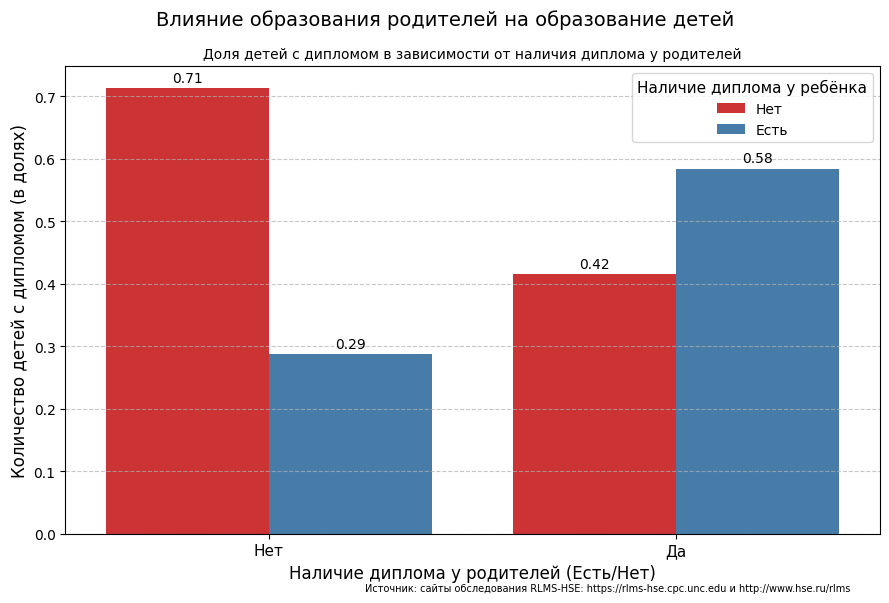

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Преобразуем pivot_percent в формат long (для seaborn)
pivot_melted = pivot_percent.reset_index().melt(
    id_vars='parent_diplom',
    var_name='child_diplom',
    value_name='percentage'
)

pivot_melted['child_diplom'] = pivot_melted['child_diplom'].map({0: 'Нет', 1: 'Есть'})

plt.figure(figsize=(9, 6))
barplot = sns.barplot(
    data=pivot_melted,
    x='parent_diplom',
    y='percentage',
    hue='child_diplom',
    palette='Set1'
)

plt.suptitle("Влияние образования родителей на образование детей", fontsize=14)
plt.title("Доля детей с дипломом в зависимости от наличия диплома у родителей", fontsize=10)

plt.xlabel("Наличие диплома у родителей (Есть/Нет)", fontsize=12)
plt.ylabel("Количество детей с дипломом (в долях)", fontsize=12)

plt.xticks([0, 1], ['Нет', 'Да'], fontsize=11)
plt.legend(title='Наличие диплома у ребёнка', title_fontsize=11, fontsize=10)

# Сетка и источник данных
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.figtext(0.95, 0.01, "Источник: сайты обследования RLMS-HSE: https://rlms-hse.cpc.unc.edu и http://www.hse.ru/rlms", horizontalalignment='right', fontsize=7)

# Добавляем значения над столбиками
for bar in barplot.patches:
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    if y > 0:
        plt.text(x=x, y=y + 0.01, s=f'{y:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 4.3 Формулировка и проверка гипотез IV

1. Изучите доступные в RLMS данные и сформулируйте три разные гипотезы о том, какие характеристики родителей могут влиять на те же самые (или другие!) характеристики детей (помимо образования). При формулировке гипотез обязательно приведите ссылки на релевантные, актуальные и авторитетные источники (научные исследования по схожей проблематике на зарубежном статистическом материале).

2. Проверьте ваши гипотезы на данных. Для этого сформулируйте необходимые разрезы данных, рассчитайте статистики, визуализируйте (в виде графиков или таблиц) ваши расчёты. Сделайте вывод о том, как результаты соотносятся со сформулированными гипотезами.

3. Кратко охарактеризуйте результаты вашего исследования в рамках одного абзаца текста.

**Гипотезы, сформулированные на основе доступных в RLMS данных:**

**Гипотеза №1: "Существует зависимость между размерами населённого пункта, в котором проживают родители, и склонностью их детей к территориальной мобильности: чем меньше населённый пункт, тем выше вероятность миграции следующего поколения."**

Исследуем тему миграции: предположим, среди детей, чьи родители живут в небольшом городе/деревне, чаще встречаются случаи переезда в другой населенный пункт. Обратимся к исследованиям, опубликованным в авторитетных изданиях, на основе которых определили гипотезу.

Международные исследования подтверждают, что существует связь между характеристиками родительской среды и склонностью молодого поколения к миграции. Так, например, исследование, проведенное в Европе, подчеркивает, что недостаточная транспортная инфраструктура и ограниченный доступ к образованию, а также работе в сельской местности усиливают потребность в территориальной мобильности, особенно среди молодежи

Так же, в исследовании ученых из Колумбии, которые рассматривали сектор крупного рогатого скота, в котором не хватает рабочей силы в их регионе, был сделан вывод о том, что подобная ситуация произошла из-за миграции молодежи, которая уезжает в поисках лучшей жизни и более высоких заработных плат в город

Однако в США тенденция другая, в статье "Internal Migration in the United States" (Molloy, Smith & Wozniak, 2011) исследователи приходят к выводу о том, что в США за последние 30 лет внутренняя миграция снизилась, от части это связано с изменениями в структуре семей, а так же уделяется внимание, что эта тенденция сохраняется и среди молодежи, живущей в сельской местности.


Список литературы:
* <div class="csl-entry">Junaid, M., Ferretti, M., &#38; Marinelli, G. (2025). Innovation and Sustainable Solutions for Mobility in Rural Areas: A Comparative Analysis of Case Studies in Europe. <i>Sustainability</i>, <i>17</i>(3), 871. https://doi.org/10.3390/su17030871</div>

*   <div class="csl-entry">Díaz Baca, M. F., Moreno Lerma, L., Burkart, S., &#38; Triana Ángel, N. (2024). Why do rural youth migrate? Evidence from Colombia and Guatemala. <i>Frontiers in Sociology</i>. https://doi.org/10.3389/fsoc.2024.1439256</div>

* Molloy, Raven; Smith, Christopher L.; Wozniak, Abigail (2011) : Internal migration
in the United States, IZA Discussion Papers, No. 5903, Institute for the Study of Labor (IZA), Bonn,
https://nbn-resolving.de/urn:nbn:de:101:1-201108152107


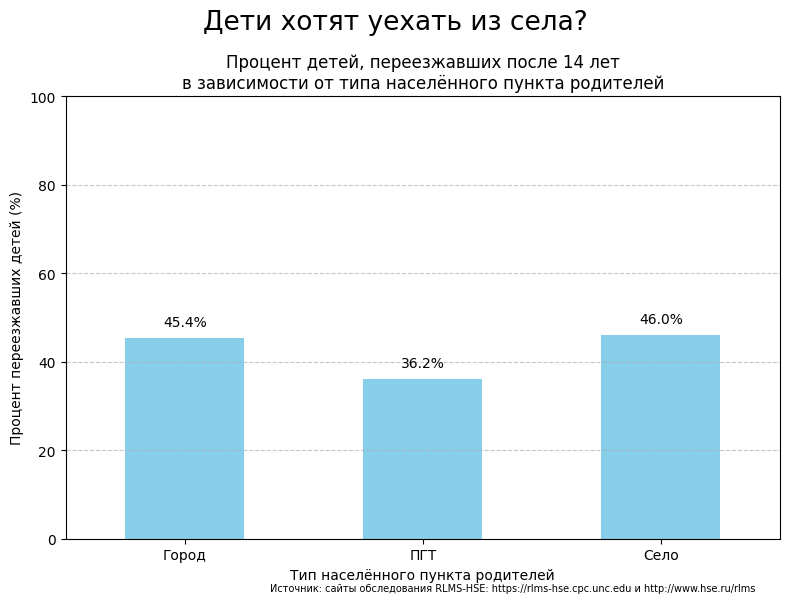

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

children_df = filtered_children.copy()
rlms_df = rlms_df_i_23.copy()

rlms_df = rlms_df[['idind', 'bbi3', 'bbi3.1']]

father_df = rlms_df.rename(columns={'idind': 'father_id', 'bbi3': 'father_bbi3'})
mother_df = rlms_df.rename(columns={'idind': 'mother_id', 'bbi3': 'mother_bbi3'})
child_df  = rlms_df.rename(columns={'idind': 'child_id', 'bbi3.1': 'child_bbi3_1'})

# Объединение
merged = children_df.merge(father_df[['father_id', 'father_bbi3']], on='father_id', how='left')
merged = merged.merge(mother_df[['mother_id', 'mother_bbi3']], on='mother_id', how='left')
merged = merged.merge(child_df[['child_id', 'child_bbi3_1']], on='child_id', how='left')

# Фильтрация корректных записей
merged = merged[
    merged['father_bbi3'].isin([1, 2, 3]) &
    merged['mother_bbi3'].isin([1, 2, 3])
]

# Макс. тип населённого пункта родителей
merged['max_parent_bbi3'] = merged[['father_bbi3', 'mother_bbi3']].max(axis=1)

# Карта значений
bbi3_map = {1: 'Город', 2: 'ПГТ', 3: 'Село'}
merged['parent_place'] = merged['max_parent_bbi3'].map(bbi3_map)

# Вычисление процентов переезда
grouped_total = merged.groupby('parent_place').size()
grouped_moved = merged[merged['child_bbi3_1'].isin([1, 2])].groupby('parent_place').size()

# Расчёт долей
percent_moved = (grouped_moved / grouped_total * 100).round(1)

ax = percent_moved.plot(kind='bar', figsize=(8, 6), color='skyblue')
plt.suptitle("Дети хотят уехать из села?", fontsize=19)
plt.figtext(0.95, 0.01, "Источник: сайты обследования RLMS-HSE: https://rlms-hse.cpc.unc.edu и http://www.hse.ru/rlms", horizontalalignment='right', fontsize=7)
plt.title('Процент детей, переезжавших после 14 лет\nв зависимости от типа населённого пункта родителей')
plt.xlabel('Тип населённого пункта родителей')
plt.ylabel('Процент переезжавших детей (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавление подписей на столбцы
for i, val in enumerate(percent_moved):
    plt.text(i, val + 2, f'{val}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


**Вывод:**

График показывает, что дети из села наиболее склонны к переезду, с показателем 46%. Это подтверждает предположение, что дети из небольших населённых пунктов стремится к миграции, предположительно, из-за ограниченных возможностей в образовании и трудоустройстве.

Дети из городов также демонстрируют высокий уровень миграции — 45.4%. Это может быть связано с тем, что в городах больше возможностей для переезда в другие регионы ради учёбы или работы.

Наименьший процент переезжающих наблюдается среди детей из посёлков городского типа — 36.2%. Это может свидетельствовать о том, что в таких населённых пунктах, возможно, есть определённые преимущества, удерживающие молодёжь на месте, или же в ПГТ меньше возможностей для переезда.

Таким образом, наша гипотеза частично подтверждается: дети из сельской местности действительно чаще стремятся переехать, но уровень миграции среди городских детей также высок, что может указывать на другие факторы, влияющие на стремление к переезду.

**Гипотеза №2: "Дети имеют значительно более высокую вероятность выбора профессии, аналогичной профессии родителей"**

Предполагается, что дети с большей вероятностью выбирают профессию, аналогичную профессии одного или обоих родителей. Данная гипотеза основана на ряде исследований, демонстрирующих значительное влияние родителей на выбор карьеры их детей.

В частности, анализ данных National Educational Panel Study (NEPS) в Германии показывает, что родители оказывают большее влияние на выбор карьеры молодыми людьми, чем учителя, консультанты по вопросам карьеры или информация из Интернета (Ulrich, Frey, & Ruppert, 2018). Это объясняется тем, что родители, как правило, проводят больше времени со своими детьми, активно консультируют их и оказывают финансовую поддержку в вопросах образования и карьеры (Hurrelmann, 2007).

Многочисленные исследования подтверждают, что социальное окружение, и особенно родители, оказывают существенное, возможно, даже решающее влияние на образовательный путь и будущую карьеру детей (Berger, Keim, & Klärner, 2010). Поэтому, данная гипотеза предполагает наличие статистически значимой связи между профессией родителей и профессией, выбранной их детьми, что отражает тенденцию к профессиональному наследованию.

*Список литературы:*

•  Berger, N. S., Keim, D., & Klärner, A. (2010). Soziale Herkunft und Bildungsentscheidungen im Lebensverlauf. VS Verlag für Sozialwissenschaften.

•  Hurrelmann, K. (2007). Adoleszenz: Einführung in die sozialwissenschaftliche Jugendforschung (9th ed.). Juventa.

•  Ulrich, A., Frey, A., & Ruppert, J. (2018). The Role of Parents in Young People’s Career Choices in Germany. Psychology, 9, 2194-2206. https://doi.org/10.4236/psych.2018.98125

•  National Educational Panel Study (NEPS): Starting Cohort Grade 9, DOI: 10.5157/NEPS:SC4:7.0.0. From 2008 to 2013

In [ ]:
hypothesis_2 = filtered_children[['child_id', 'father_id', 'mother_id']]

# Создаем словарь для сопоставления idind -> bbj4.1
profession_dict = rlms_df_i_23.set_index('idind')['bbj4.1'].to_dict()

# Добавляем новые столбцы в hypothesis_2
hypothesis_2['child_profession'] = hypothesis_2['child_id'].map(profession_dict)
hypothesis_2['father_profession'] = hypothesis_2['father_id'].map(profession_dict)
hypothesis_2['mother_profession'] = hypothesis_2['mother_id'].map(profession_dict)

# Список значений, которые нужно заменить на NaN
values_to_replace = [99999996, 99999997, 99999998, 99999999]

columns_to_clean = ['child_profession', 'father_profession', 'mother_profession']
hypothesis_2[columns_to_clean] = hypothesis_2[columns_to_clean].replace(values_to_replace, np.nan)

all_professions = pd.concat([hypothesis_2[col] for col in columns_to_clean], axis=0)
profession_counts = all_professions.value_counts()

rare_professions = profession_counts[profession_counts < 13].index

# Заменить редкие профессии на NaN
for col in columns_to_clean:
    hypothesis_2[col] = hypothesis_2[col].apply(lambda x: np.nan if x in rare_professions else x)

# Условие 1: Удалить строки, где child_profession == NaN
condition_1 = hypothesis_2['child_profession'].notna()

# Условие 2: Удалить строки, где father_profession == NaN И mother_profession == NaN
condition_2 = hypothesis_2[['father_profession', 'mother_profession']].notna().any(axis=1)

# Условие 3: Удалить строки, где child_profession > 20, father_profession > 20, mother_profession > 20
condition_3 = (hypothesis_2['child_profession'] <= 20) & \
              (hypothesis_2['father_profession'].fillna(0) <= 20) & \
              (hypothesis_2['mother_profession'].fillna(0) <= 20)

filtered_hypothesis_2 = hypothesis_2[condition_1 & condition_2 & condition_3]

filtered_hypothesis_2.info()
filtered_hypothesis_2.sample(5)

<class 'pandas.core.frame.DataFrame'>
Index: 564 entries, 1 to 4312
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   child_id           564 non-null    float64
 1   father_id          325 non-null    float64
 2   mother_id          549 non-null    float64
 3   child_profession   564 non-null    float64
 4   father_profession  262 non-null    float64
 5   mother_profession  477 non-null    float64
dtypes: float64(6)
memory usage: 30.8 KB


,child_id,father_id,mother_id,child_profession,father_profession,mother_profession
1860,48869.0,48868.0,48867.0,14.0,14.0,11.0
2579,56685.0,28536.0,56684.0,15.0,NaN,14.0
50,3119.0,3118.0,3117.0,10.0,NaN,10.0
3488,61967.0,61965.0,61966.0,12.0,15.0,9.0
1339,40773.0,NaN,40771.0,14.0,NaN,14.0


In [ ]:
# Условие: child_profession совпадает с father_profession или mother_profession
condition = (
    (filtered_hypothesis_2['child_profession'] == filtered_hypothesis_2['father_profession']) |
    (filtered_hypothesis_2['child_profession'] == filtered_hypothesis_2['mother_profession'])
)

# Подсчитываем количество совпадающих строк hit map
matching_rows_count = condition.sum()

total_rows_count = filtered_hypothesis_2.shape[0]

# Вычисляем долю совпадающих строк
matching_rows_share = (matching_rows_count / total_rows_count)

print(f"Доля семей, в которых ребенок работает в отрасли родителей равна {matching_rows_share:.2f}")

Доля семей, в которых ребенок работает в отрасли родителей равна 0.29


Общая тенденция профессионального наследования.


Доля семей, в которых дети работают в отрасли родителей, составляет **0.29**. Значит, что почти треть детей выбирают профессию, аналогичную профессии одного из родителей. Этот результат **подтверждает** наличие тенденции к профессиональному наследованию. Но мы не можем говорить о полном доминировании этого эффекта.

<ipython-input-40-8c59bff0f321>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hypothesis_2["parent_profession"] = filtered_hypothesis_2.apply(determine_parent_profession, axis=1)


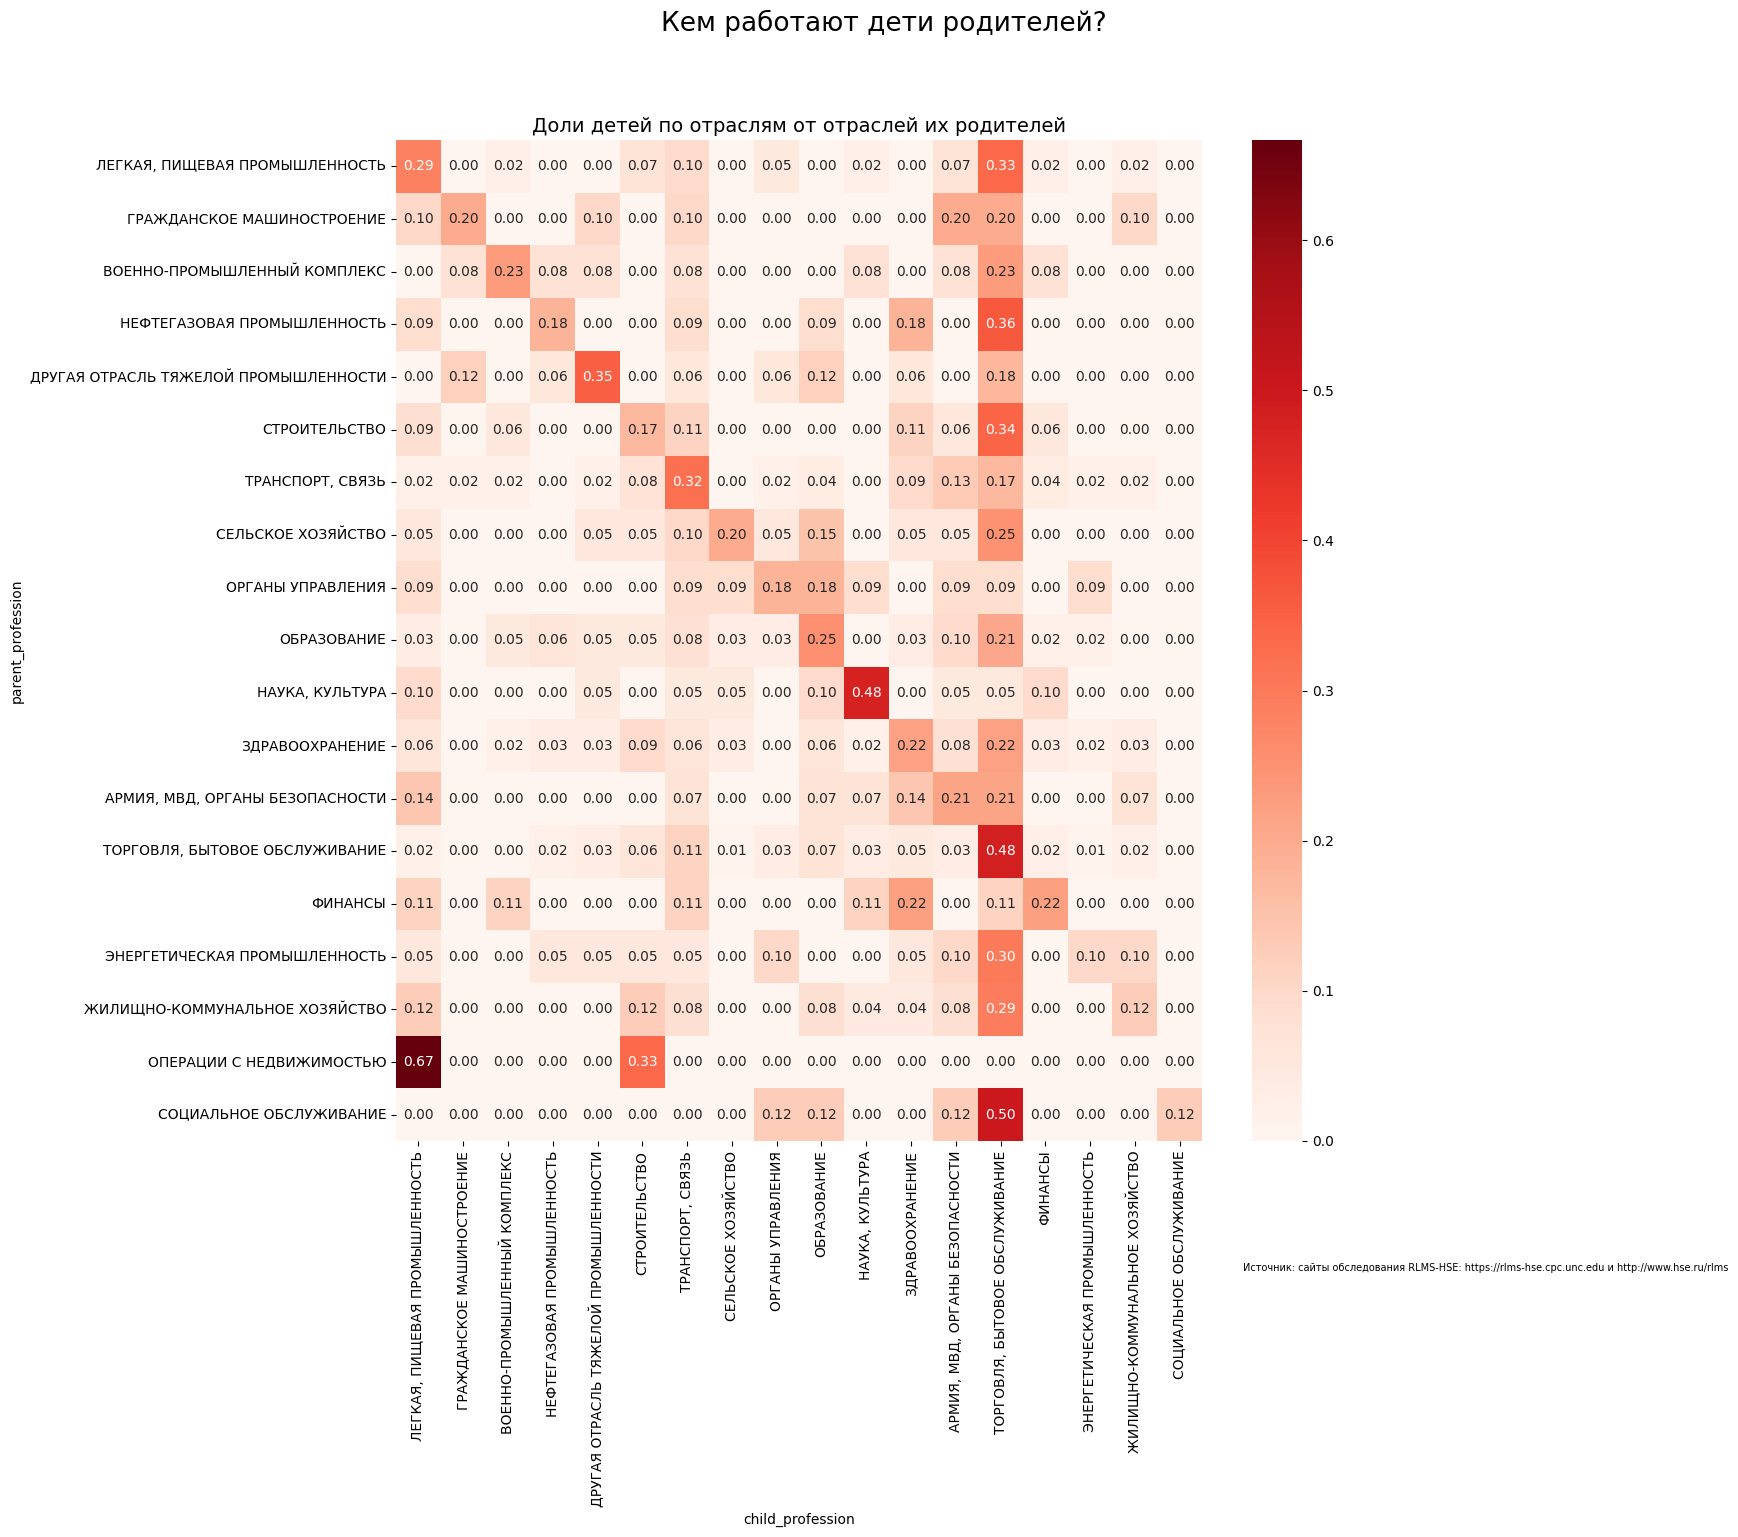

In [ ]:
# Функция для определения профессии родителя
def determine_parent_profession(row):
    if row["child_profession"] == row["father_profession"]:
        return row["father_profession"]
    elif row["child_profession"] == row["mother_profession"]:
        return row["mother_profession"]
    else:
        return row["father_profession"] if pd.notna(row["father_profession"]) else row["mother_profession"]

filtered_hypothesis_2["parent_profession"] = filtered_hypothesis_2.apply(determine_parent_profession, axis=1)

profession_names = {
    1: "ЛЕГКАЯ, ПИЩЕВАЯ ПРОМЫШЛЕННОСТЬ",
    2: "ГРАЖДАНСКОЕ МАШИНОСТРОЕНИЕ",
    3: "ВОЕННО-ПРОМЫШЛЕННЫЙ КОМПЛЕКС",
    4: "НЕФТЕГАЗОВАЯ ПРОМЫШЛЕННОСТЬ",
    5: "ДРУГАЯ ОТРАСЛЬ ТЯЖЕЛОЙ ПРОМЫШЛЕННОСТИ",
    6: "СТРОИТЕЛЬСТВО",
    7: "ТРАНСПОРТ, СВЯЗЬ",
    8: "СЕЛЬСКОЕ ХОЗЯЙСТВО",
    9: "ОРГАНЫ УПРАВЛЕНИЯ",
    10: "ОБРАЗОВАНИЕ",
    11: "НАУКА, КУЛЬТУРА",
    12: "ЗДРАВООХРАНЕНИЕ",
    13: "АРМИЯ, МВД, ОРГАНЫ БЕЗОПАСНОСТИ",
    14: "ТОРГОВЛЯ, БЫТОВОЕ ОБСЛУЖИВАНИЕ",
    15: "ФИНАНСЫ",
    16: "ЭНЕРГЕТИЧЕСКАЯ ПРОМЫШЛЕННОСТЬ",
    17: "ЖИЛИЩНО-КОММУНАЛЬНОЕ ХОЗЯЙСТВО",
    18: "ОПЕРАЦИИ С НЕДВИЖИМОСТЬЮ",
    20: "СОЦИАЛЬНОЕ ОБСЛУЖИВАНИЕ"
}

# Переименовываем индексы и столбцы в сводной таблице
pivot_table = filtered_hypothesis_2.pivot_table(
    index="parent_profession",
    columns="child_profession",
    aggfunc="size",
    fill_value=0
)

pivot_table.index = pivot_table.index.map(profession_names)
pivot_table.columns = pivot_table.columns.map(profession_names)

# Рассчитываем доли: делим каждую ячейку на сумму в соответствующей строке (по профессии родителя)
pivot_table_dol = pivot_table.div(pivot_table.sum(axis=1), axis=0)

plt.figure(figsize=(13, 13))
plt.suptitle("Кем работают дети родителей?", fontsize=19)
plt.title("Доли детей по отраслям от отраслей их родителей", fontsize=14)
plt.ylabel("Отрасль родителей")
plt.xlabel("Отрасль ребенка")
plt.xticks(rotation=45)
sns.heatmap(pivot_table_dol, annot=True, fmt=".2f", cmap="Reds")
plt.figtext(1.15, 0.01, "Источник: сайты обследования RLMS-HSE: https://rlms-hse.cpc.unc.edu и http://www.hse.ru/rlms", horizontalalignment='right', fontsize=7)
plt.show()


**Анализ hit map**

На тепловой карте видно, что вероятность выбора детьми профессии родителей сильно зависит от конкретной отрасли:

- Самая сильная связь наблюдается в сфере "Операции с недвижимостью" — здесь 67% детей выбирают профессию своих родителей. Это может быть связано с тем, что работа в этой сфере требует специфических знаний и связей, которые передаются внутри семьи.

- Высокая вероятность наследования профессии также есть в:
 - Образовании — 48% детей становятся педагогами, как их родители.
 - Социальном обслуживании — 50% детей продолжают работать в этой сфере, возможно, благодаря семейным ценностям и приверженности к помощи людям.

- Средний уровень связи наблюдается в таких отраслях, как:
 - Нефтегазовая промышленность — 36%.
 - Тяжелая промышленность — 35%.
 - Транспорт и связь — 34%.

Эти профессии требуют устойчивых навыков и опыта, которые, вероятно, передаются родителями.

- Слабая связь или почти полное отсутствие наследования профессии отмечается в областях:
 - Сельское хозяйство — 25%.
 - Гражданское машиностроение — 20%.
 - Легкая и пищевая промышленность — 29%.

Эти отрасли могут быть менее привлекательными для молодых людей или не требовать сильной преемственности.

**Выводы**

На основании предоставленных данных гипотеза №2 подтверждается частично. Хотя значительная часть детей выбирает профессию, аналогичную профессии родителей, это не является законом. Вероятность профессионального наследования зависит от отрасли. Наиболее выраженные тенденции наблюдаются в сферах, где профессиональные навыки, доступ к ресурсам или семейные ценности играют ключевую роль.

Также хотелось бы отметить, что во время исследования мы столкнулись с ограничениями выборки данных.
Так, после применения фильтров для проверки конкретных гипотез размер выборки существенно сокращался. В некоторых случаях после фильтрации оставалось менее 100 наблюдений, что ограничивает статистическую значимость полученных выводов и повышает чувствительность результатов к выбросам и единичным случаям.
Также в предоставленном датасете отсутствовали некоторые вопросы, указанные в оригинальном опроснике RLMS-HSE. Это ограничивало возможности анализа и проверки дополнительных гипотез, в частности, касающихся уровня образования, доходов или детализированных характеристик профессий.

**Гипотеза №3: "Дети, выросшие в семьях с одним или обоими родителями, употреблявшими алкоголь или курившими, имеют значительно более высокий риск развития тех же зависимостей"**

Мы предполагаем, что дети, чьи родители вели нездоровый образ жизни, с большей вероятностью будут так же наносить вред своему здоровью пагубными привычками в будущем. По этой теме есть немало современных научных исследований, опираясь на которые была сформулирована гипотеза.

Например, согласно финскому исследованию, опубликованному в European Journal Of Public Health, курение отца больше 10 сигарет в день до беременности в 5,5 раз повышают риск появления проблем, связанных с употреблением психоактивных веществ у потомства.

Что касается влияния матери, исследование, проведенное учеными из Гарвардского университета, показало, что воздействие материнского расстройства, связанного с употреблением психоактивных веществ, увеличило риск появления такой же проблемы у потомства в 2,7 раз.

Так же, качественное исследование, проведенное в Бельгии, позволило взглянуть на проблему изнутри: участники исследования, выросшие в семьях с родителями, страдающими зависимостями, описывали детсво как период изоляции, стыда и нехватки эмоциаональной поддержки. Такие травмы спровоцировали расстройство, связанное с употреблением психоактивных веществ.



*Список литературы:*

* <div class="csl-entry">Sarala, M., Mustonen, A., Alakokkare, A.-E., Salom, C., Miettunen, J., &#38; Niemelä, S. (2022). Parental smoking and young adult offspring psychosis, depression and anxiety disorders and substance use disorder. <i>European Journal of Public Health</i>, <i>32</i>, 254–260. https://doi.org/10.1093/eurpub/ckac004</div>

*   <div class="csl-entry">Yule, A., Wilens, T. E., Martelon, M., Rosenthal, L., &#38; Biederman, J. (2018). Does exposure to parental substance use disorders increase offspring risk for a substance use disorder? A longitudinal follow-up study into young adulthood. <i>Drug and Alcohol Dependence</i>, <i>186</i>, 154–158. https://doi.org/10.1016/J.DRUGALCDEP.2018.01.021</div>

*   <div class="csl-entry">Meulewaeter, F., De Schauwer, E., De Pauw, S., &#38; Vanderplasschen, W. (2022). I Grew Up Amidst Alcohol and Drugs:” a Qualitative Study on the Lived Experiences of Parental Substance Use Among Adults Who Developed Substance Use Disorders Themselves. <i>Frontiers in Psychiatry</i>, <i>13</i>. https://doi.org/10.3389/fpsyt.2022.768802</div>


In [ ]:
# Скачиваем файл
# Идивиды 2014
file_id = '1Th9opOQXGxGXf-nmBsfsSxAYGHs0lj79'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'r23i_os_74.sav'
gdown.download(url, output, quiet=False)
# Читаем SPSS-файл
try:
    rlms_df_i_14 = pd.read_spss(output, convert_categoricals=False) # тут мы и делаем рекодирование - convert_categoricals=False
    print("Файл успешно загружен!")
except Exception as e:
    print(f"Ошибка загрузки: {e}")

Downloading...
From: https://drive.google.com/uc?id=1Th9opOQXGxGXf-nmBsfsSxAYGHs0lj79
To: /content/r23i_os_74.sav
100%|██████████| 18.2M/18.2M [00:00<00:00, 68.2MB/s]


Файл успешно загружен!


In [ ]:

#Переименование колонок возраста
if 'bb_age' in rlms_df_i_23.columns:
    rlms_df_i_23.rename(columns={'bb_age': 'child_age_2023'}, inplace=True)
    print("Колонка 'bb_age' переименована в 'child_age_2023' в rlms_df_i_23.")
else:
    print("Ошибка: Колонка 'bb_age' не найдена в rlms_df_i_23. Проверьте название колонки.")

if 's_age' in rlms_df_i_14.columns:
    rlms_df_i_14.rename(columns={'s_age': 'parent_age_2014'}, inplace=True)
    print("Колонка 's_age' переименована в 'parent_age_2014' в rlms_df_i_14.")
else:
    print("Ошибка: Колонка 's_age' не найдена в rlms_df_i_14. Проверьте название колонки.")

# Проверка наличия ключевых колонок для объединения
required_cols_children_file = ['child_id', 'father_id', 'mother_id']
if not all(col in filtered_children.columns for col in required_cols_children_file):
    print(f"Ошибка: В файле filtered_children.csv отсутствуют одна или несколько колонок из: {required_cols_children_file}")
    exit()

if 'idind' not in rlms_df_i_23.columns:
    print("Ошибка: Колонка 'idind' не найдена в rlms_df_i_23.")
    exit()
if 'idind' not in rlms_df_i_14.columns:
    print("Ошибка: Колонка 'idind' не найдена в rlms_df_i_14.")
    exit()

# Объединение filtered_children с данными детей из rlms_df_i_23
print("Объединение filtered_children с rlms_df_i_23...")
final_df = pd.merge(filtered_children, rlms_df_i_23, left_on='child_id', right_on='idind', how='left')
if 'idind_x' in final_df.columns and 'idind_y' in final_df.columns:
    final_df.drop(columns=['idind_y'], inplace=True)
    final_df.rename(columns={'idind_x': 'idind_child'}, inplace=True)


# Объединение с данными отцов из rlms_df_i_14
print("Объединение с данными отцов (rlms_df_i_14)...")
final_df = pd.merge(final_df, rlms_df_i_14.add_prefix('father_'), left_on='father_id', right_on='father_idind', how='left')

# Объединение с данными матерей из rlms_df_i_14
print("Объединение с данными матерей (rlms_df_i_14)...")
final_df = pd.merge(final_df, rlms_df_i_14.add_prefix('mother_'), left_on='mother_id', right_on='mother_idind', how='left')

print(f"Размер итогового DataFrame после объединений: {final_df.shape}")

Колонка 'bb_age' переименована в 'child_age_2023' в rlms_df_i_23.
Колонка 's_age' переименована в 'parent_age_2014' в rlms_df_i_14.
Объединение filtered_children с rlms_df_i_23...
Объединение с данными отцов (rlms_df_i_14)...
Объединение с данными матерей (rlms_df_i_14)...
Размер итогового DataFrame после объединений: (4396, 2585)


In [ ]:
# Переменная курения родителей в 2014 году (когда ребенок рос)
codes_to_nan = [99999997, 99999998, 99999999, 99999996]

if 'father_sm71' in final_df.columns:
    final_df['father_smokes_2014'] = final_df['father_sm71'].replace(codes_to_nan, np.nan).replace({1: 1, 2: 0})
    print("Создана колонка 'father_smokes_2014'.")
else:
    print("Предупреждение: Колонка 'father_sm71' не найдена. 'father_smokes_2014' не создана.")
    final_df['father_smokes_2014'] = np.nan

if 'mother_sm71' in final_df.columns:
    final_df['mother_smokes_2014'] = final_df['mother_sm71'].replace(codes_to_nan, np.nan).replace({1: 1, 2: 0})
    print("Создана колонка 'mother_smokes_2014'.")
else:
    print("Предупреждение: Колонка 'mother_sm71' не найдена. 'mother_smokes_2014' не создана.")
    final_df['mother_smokes_2014'] = np.nan

final_df['parent_smoked_2014'] = ((final_df['father_smokes_2014'].fillna(0) == 1) | \
                                   (final_df['mother_smokes_2014'].fillna(0) == 1)).astype(int)
print("Создана колонка 'parent_smoked_2014'.")

# Переменные курения для детей из опроса 2023 года
if 'bbm72' in final_df.columns:
    final_df['child_smoking_start_age'] = final_df['bbm72'].replace(codes_to_nan, np.nan)
    final_df['child_smoking_start_age'] = pd.to_numeric(final_df['child_smoking_start_age'], errors='coerce')
    print("Создана колонка 'child_smoking_start_age'.")
else:
    print("Ошибка: Колонка 'bbm72' не найдена. 'child_smoking_start_age' не создана.")
    final_df['child_smoking_start_age'] = np.nan

if 'bbm71' in final_df.columns:
    final_df['child_smokes_now_2023'] = final_df['bbm71'].replace(codes_to_nan, np.nan).replace({1: 1, 2: 0})
    print("Создана колонка 'child_smokes_now_2023'.")
else:
    print("Ошибка: Колонка 'bbm71' не найдена. 'child_smokes_now_2023' не создана.")
    final_df['child_smokes_now_2023'] = np.nan

# Ребенок должен был быть младше 18 лет в 2014 году.
# Это означает, что в 2023 году его возраст child_age_2023 должен быть < (18 + 9) = 27 лет.
if 'child_age_2023' in final_df.columns:
    final_df['child_age_2023'] = pd.to_numeric(final_df['child_age_2023'], errors='coerce')
    initial_rows = final_df.shape[0]
    final_df.dropna(subset=['child_age_2023'], inplace=True) # Удаляем тех, у кого нет возраста
    final_df = final_df[final_df['child_age_2023'] < 27].copy() # Применяем фильтр
    print(f"Применен фильтр по возрасту ребенка: child_age_2023 < 27 (т.е. < 18 лет в 2014).")
    print(f"Количество строк до фильтра по возрасту: {initial_rows}, после: {final_df.shape[0]}")
else:
    print("Предупреждение: Колонка 'child_age_2023' не найдена. Фильтр по возрасту ребенка не применен.")

Создана колонка 'father_smokes_2014'.
Создана колонка 'mother_smokes_2014'.
Создана колонка 'parent_smoked_2014'.
Создана колонка 'child_smoking_start_age'.
Создана колонка 'child_smokes_now_2023'.
Применен фильтр по возрасту ребенка: child_age_2023 < 27 (т.е. < 18 лет в 2014).
Количество строк до фильтра по возрасту: 4396, после: 2900


<ipython-input-44-12a32b77ea4b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df['child_smoking_start_age'] = pd.to_numeric(analysis_df['child_smoking_start_age'], errors='coerce')
<ipython-input-44-12a32b77ea4b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df.dropna(subset=['child_smoking_start_age'], inplace=True)



Размер DataFrame для анализа после удаления пропусков по курению: (150, 2590)


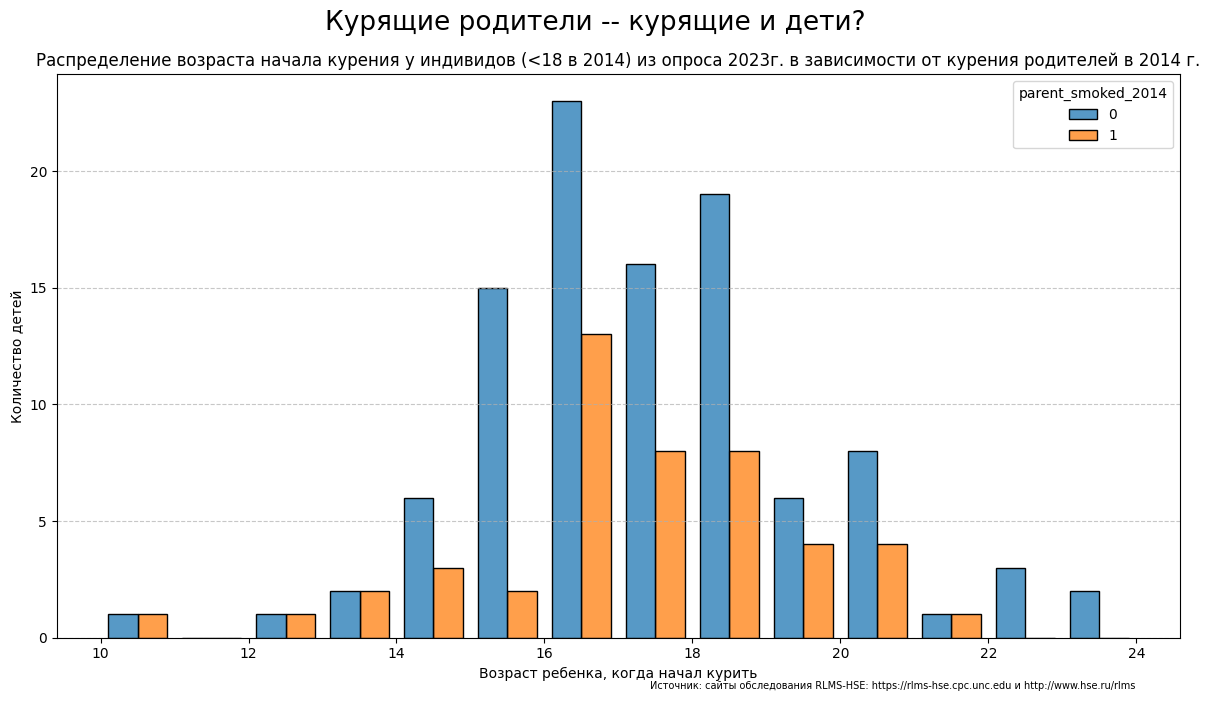

In [ ]:
# Оставляем только тех детей, для которых есть информация о возрасте начала курения и о том, курили ли родители
analysis_df = final_df.dropna(subset=['child_smoking_start_age', 'parent_smoked_2014'])

# Убедимся, что возраст начала курения - это число
analysis_df['child_smoking_start_age'] = pd.to_numeric(analysis_df['child_smoking_start_age'], errors='coerce')
analysis_df.dropna(subset=['child_smoking_start_age'], inplace=True)

print(f"\nРазмер DataFrame для анализа после удаления пропусков по курению: {analysis_df.shape}")

if analysis_df.empty:
    print("После удаления пропусков не осталось данных для анализа. Проверьте данные и фильтры.")
else:
    plt.figure(figsize=(12, 7))
    sns.histplot(data=analysis_df,
                 x='child_smoking_start_age',
                 hue='parent_smoked_2014',
                 multiple='dodge',
                 kde=False,
                 binwidth=1,
                 shrink=0.8)

    plt.title('Распределение возраста начала курения у индивидов (<18 в 2014) из опроса 2023г. в зависимости от курения родителей в 2014 г.')
    plt.xlabel('Возраст ребенка, когда начал курить')
    plt.ylabel('Количество детей')

    handles, labels = plt.gca().get_legend_handles_labels()

    # Сетка и источник данных
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.suptitle("Курящие родители -- курящие и дети?", fontsize=19)
    plt.figtext(0.95, 0.01, "Источник: сайты обследования RLMS-HSE: https://rlms-hse.cpc.unc.edu и http://www.hse.ru/rlms", horizontalalignment='right', fontsize=7)

    if len(labels) >= 2:
      try:
          label_map = {str(float(val)): ('Родитель НЕ курил в 2014' if val == 0 else 'Родитель курил в 2014') for val in sorted(analysis_df['parent_smoked_2014'].unique()) if not pd.isna(val)}
          ordered_new_labels = [label_map[lbl] for lbl in labels if lbl in label_map]
          if ordered_new_labels: # Если удалось сопоставить
             plt.legend(handles, ordered_new_labels, title='Статус курения родителей в 2014')
          else: # Если не удалось, используем стандартные
             plt.legend(title='Статус курения родителей в 2014 (0=Нет, 1=Да)')
      except Exception as e:
          print(f"Не удалось настроить легенду автоматически: {e}. Используется стандартная легенда.")
          plt.legend(title='Статус курения родителей в 2014 (0=Нет, 1=Да)')
    elif len(labels) == 1: # Если только одна группа после всех фильтров
        try:
            single_label_val = float(labels[0])
            single_label_text = 'Родитель НЕ курил в 2014' if single_label_val == 0 else 'Родитель курил в 2014'
            plt.legend(handles, [single_label_text], title='Статус курения родителей в 2014')
        except:
            plt.legend(title='Статус курения родителей в 2014')


    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

In [ ]:

    if 1 in analysis_df['parent_smoked_2014'].unique():
        mean_age_parent_smoked = analysis_df[analysis_df['parent_smoked_2014'] == 1]['child_smoking_start_age'].mean()
        print(f"\nСредний возраст начала курения (родители курили, дети <18 в 2014): {mean_age_parent_smoked:.2f} лет")
    else:
        print("\nНет данных для группы 'родители курили' после фильтрации.")

    if 0 in analysis_df['parent_smoked_2014'].unique():
        mean_age_parent_not_smoked = analysis_df[analysis_df['parent_smoked_2014'] == 0]['child_smoking_start_age'].mean()
        print(f"Средний возраст начала курения (родители НЕ курили, дети <18 в 2014): {mean_age_parent_not_smoked:.2f} лет")
    else:
        print("Нет данных для группы 'родители НЕ курили' после фильтрации.")


    if 'child_smokes_now_2023' in analysis_df.columns:
        # Используем final_df до фильтрации по child_smoking_start_age для более общей картины по child_smokes_now_2023
        # но с уже примененным фильтром по возрасту ребенка (<18 в 2014)
        temp_df_smokes_now = final_df.dropna(subset=['parent_smoked_2014', 'child_smokes_now_2023'])
        if not temp_df_smokes_now.empty:
            if 1 in temp_df_smokes_now['parent_smoked_2014'].unique():
                proportion_smokes_now_parent_smoked = temp_df_smokes_now[temp_df_smokes_now['parent_smoked_2014'] == 1]['child_smokes_now_2023'].value_counts(normalize=True).get(1, 0)
                print(f"Доля курящих сейчас детей (дети <18 в 2014, родители курили в 2014): {proportion_smokes_now_parent_smoked:.2%}")
            else:
                print("Нет данных для расчета доли курящих сейчас (родители курили) после фильтрации.")

            if 0 in temp_df_smokes_now['parent_smoked_2014'].unique():
                proportion_smokes_now_parent_not_smoked = temp_df_smokes_now[temp_df_smokes_now['parent_smoked_2014'] == 0]['child_smokes_now_2023'].value_counts(normalize=True).get(1, 0)
                print(f"Доля курящих сейчас детей (дети <18 в 2014, родители НЕ курили в 2014): {proportion_smokes_now_parent_not_smoked:.2%}")
            else:
                print("Нет данных для расчета доли курящих сейчас (родители НЕ курили) после фильтрации.")
        else:
            print("Недостаточно данных для расчета долей курящих сейчас детей после удаления пропусков (с учетом фильтра по возрасту <18 в 2014).")
    else:
        print("Колонка 'child_smokes_now_2023' отсутствует, расчет долей курящих сейчас невозможен.")



Средний возраст начала курения (родители курили, дети <18 в 2014): 16.70 лет
Средний возраст начала курения (родители НЕ курили, дети <18 в 2014): 16.97 лет
Доля курящих сейчас детей (дети <18 в 2014, родители курили в 2014): 11.73%
Доля курящих сейчас детей (дети <18 в 2014, родители НЕ курили в 2014): 10.09%


**Вывод:**
Анализ данных RLMS показал, что наличие курящих родителей не сильно влияет на курение их детей.
Среди детей младше 18 лет:

- Средний возраст начала курения у тех, чьи родители курили, составил 16.70 лет,
а у тех, чьи родители не курили — 16.97 лет. Разница всего 0.27 года, что указывает на слабую зависимость между курением родителей и возрастом начала курения детей.

- Доля курящих среди детей, чьи родители курили — 11.73%,
а среди детей из некурящих семей — 10.09%. Разница в 1.64 процентных пункта, что также говорит о небольшом влиянии факта курения родителей на приверженность ребёнка.

Таким образом, проанализировав предоставленные данные, наша гипотеза не подтвердилась: с одной стороны, родители могут демонстрировать поведенческую норму, провоцируя курение; с другой стороны, у детей может развиваться отвращение к курению, когда они видят негативные аспекты этой привычки у родителей — запах, поведение, физиологические последствия. В результате эти эффекты частично компенсируют друг друга, что и отражается в почти одинаковых показателях между двумя группами.

**Вывод по всей проделанной работе:**

В ходе проведённого исследования были рассмотрены три гипотезы, каждая из которых позволила глубже понять социальные и поведенческие процессы, влияющие на жизнь молодого поколения. Общий вывод заключается в том, что каждая из гипотез подтвердилась частично, отражая сложность и многогранность исследуемых явлений. Эти гипотезы важны, потому что они помогают лучше понять, как устроена жизнь общества, и могут быть полезны для принятия решений, которые сделают её лучше. Например, вопрос о том, почему молодёжь переезжает из деревень в города, важен для того, чтобы развивать регионы и улучшать жизнь в сельской местности. Исследование Junaid и коллег (2025) показало, что для этого нужно создавать удобные условия для жизни и работы в деревнях. Таким образом, результаты исследования подчёркивают сложность социальных процессов, где влияние родительской среды, инфраструктуры и культурных факторов переплетается.